# 05. Advanced Models 

Continuing from `cleaned_preprocessed_data.csv` (02_preprocessing.ipynb, including the Week 6 engineered features `BedBathRatio` / `PropertyAge` / `SchoolDistrictGIS`, with `Latitude`/`Longitude` excluded).

Here we try a gradient boosting model (XGBoost), do a light hyperparameter search over `max_depth` / `learning_rate` / `n_estimators`, and report test-set metrics - including a like-for-like comparison against Linear Regression and Random Forest retrained on this exact same data, since `03_baseline_model.ipynb` / `04_model_comparison.ipynb` were built before the Week 6 feature set existed and shouldn't be assumed comparable until they're re-run.

**Note on tuning methodology**: earlier notebooks (e.g. the train-window search in 02_preprocessing.ipynb) picked their setting by checking directly against the test month. Here a proper validation split carved out of the training window is used for hyperparameter tuning instead, so the true test month stays untouched until the very last step (section 6).


In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs xgboost. Install with: pip install xgboost "
        "(LightGBM - `pip install lightgbm` - would work as a drop-in alternative, "
        "swap XGBRegressor for lightgbm.LGBMRegressor if preferred)"
    ) from e

RANDOM_STATE = 42


## 1. Load cleaned dataset


In [2]:
cleaned_df = pd.read_csv("cleaned_preprocessed_data.csv", low_memory=False)
print(cleaned_df.shape)
cleaned_df["split"].value_counts()


(83495, 121)


split
train     59442
unused    12029
test      12024
Name: count, dtype: int64

## 2. Separate features / target using the `split` column

Same pattern as 03_baseline_model.ipynb / 04_model_comparison.ipynb: `split == "train"` for training, `split == "test"` for the held-out final evaluation (the most recent month, never touched until section 6).


In [3]:
target = "ClosePrice"
meta_cols = [target, "date", "year_month", "split"]

train_df = cleaned_df[cleaned_df["split"] == "train"].copy()
test_df = cleaned_df[cleaned_df["split"] == "test"].copy()

feature_cols = [c for c in cleaned_df.columns if c not in meta_cols]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (59442, 117) | X_test: (12024, 117)


## 3. Carve out a validation split from the training window (for tuning only)

The last month inside the training window is held out as a validation month; hyperparameter combinations are scored against it in section 4. The true test month (section 2) is never used until the single final evaluation in section 6.


In [4]:
months_in_train = sorted(train_df["year_month"].unique())
val_month = months_in_train[-1]
tune_train_months = months_in_train[:-1]

tune_train_df = train_df[train_df["year_month"].isin(tune_train_months)]
tune_val_df = train_df[train_df["year_month"] == val_month]

X_tune_train = tune_train_df[feature_cols]
y_tune_train = tune_train_df[target]

X_tune_val = tune_val_df[feature_cols]
y_tune_val = tune_val_df[target]

print(f"Tuning train months: {tune_train_months}")
print(f"Validation month: {val_month}")
print(f"X_tune_train: {X_tune_train.shape} | X_tune_val: {X_tune_val.shape}")


Tuning train months: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03']
Validation month: 2026-04
X_tune_train: (47411, 117) | X_tune_val: (12031, 117)


## 4. Light hyperparameter search

A small grid over the three hyperparameters called out in the requirements - `max_depth`, `learning_rate`, `n_estimators` - kept intentionally small (candidates below give 3 × 2 × 2 = 12 combinations) since this is meant to be a *light* search, not an exhaustive one. Each combination is fit on `tune_train` and scored on `tune_val` only.


In [5]:
MAX_DEPTH_CANDIDATES = [3, 5, 7]
LEARNING_RATE_CANDIDATES = [0.05, 0.1]
N_ESTIMATORS_CANDIDATES = [200, 400]

tuning_results = []

for max_depth, learning_rate, n_estimators in itertools.product(
    MAX_DEPTH_CANDIDATES, LEARNING_RATE_CANDIDATES, N_ESTIMATORS_CANDIDATES
):
    model = XGBRegressor(
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_tune_train, y_tune_train)
    pred = model.predict(X_tune_val)

    tuning_results.append({
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "val_R2": r2_score(y_tune_val, pred),
        "val_MAE": mean_absolute_error(y_tune_val, pred),
        "val_RMSE": np.sqrt(mean_squared_error(y_tune_val, pred)),  # squared=False was removed in newer sklearn, so use sqrt instead
    })

    print(f"[depth={max_depth} | lr={learning_rate} | n_estimators={n_estimators}] "
          f"val_R2={tuning_results[-1]['val_R2']:.4f} | val_RMSE={tuning_results[-1]['val_RMSE']:,.0f}")


[depth=3 | lr=0.05 | n_estimators=200] val_R2=0.0088 | val_RMSE=11,708,598
[depth=3 | lr=0.05 | n_estimators=400] val_R2=-0.0021 | val_RMSE=11,773,014
[depth=3 | lr=0.1 | n_estimators=200] val_R2=-0.0045 | val_RMSE=11,787,351
[depth=3 | lr=0.1 | n_estimators=400] val_R2=-0.0190 | val_RMSE=11,872,002
[depth=5 | lr=0.05 | n_estimators=200] val_R2=-0.1308 | val_RMSE=12,506,405
[depth=5 | lr=0.05 | n_estimators=400] val_R2=-0.1376 | val_RMSE=12,543,746
[depth=5 | lr=0.1 | n_estimators=200] val_R2=-0.1368 | val_RMSE=12,539,270
[depth=5 | lr=0.1 | n_estimators=400] val_R2=-0.1404 | val_RMSE=12,559,269
[depth=7 | lr=0.05 | n_estimators=200] val_R2=0.1157 | val_RMSE=11,059,705
[depth=7 | lr=0.05 | n_estimators=400] val_R2=0.1154 | val_RMSE=11,061,336
[depth=7 | lr=0.1 | n_estimators=200] val_R2=-0.1095 | val_RMSE=12,387,923
[depth=7 | lr=0.1 | n_estimators=400] val_R2=-0.1096 | val_RMSE=12,388,238


## 5. Validation results


In [6]:
tuning_results_df = pd.DataFrame(tuning_results).sort_values("val_RMSE").reset_index(drop=True)
tuning_results_df.to_csv("advanced_model_tuning_results.csv", index=False)
print("Saved advanced_model_tuning_results.csv")
tuning_results_df


Saved advanced_model_tuning_results.csv


,max_depth,learning_rate,n_estimators,val_R2,val_MAE,val_RMSE
0,7,0.05,200,0.115653,335420.946592,1.105971e+07
1,7,0.05,400,0.115392,336724.460717,1.106134e+07
2,3,0.05,200,0.008836,395506.109719,1.170860e+07
3,3,0.05,400,-0.002100,464542.862438,1.177301e+07
4,3,0.10,200,-0.004542,478316.696617,1.178735e+07
5,3,0.10,400,-0.019022,583041.031663,1.187200e+07
6,7,0.10,200,-0.109514,354572.028421,1.238792e+07
7,7,0.10,400,-0.109570,355384.268568,1.238824e+07
8,5,0.05,200,-0.130839,406514.954763,1.250641e+07
9,5,0.10,200,-0.136790,452352.075338,1.253927e+07


## 6. Retrain the best configuration on the full training window & evaluate on the true test month

The winning hyperparameters (lowest `val_RMSE`) are refit on the **entire** training window (`X_train`/`y_train`, i.e. `tune_train` + the validation month combined) - the validation split was only a tool for picking hyperparameters, so the final model shouldn't be trained on less data than necessary. This is evaluated against the true test month exactly once.


In [7]:
best_params = tuning_results_df.iloc[0][["max_depth", "learning_rate", "n_estimators"]].to_dict()
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])
print(f"Best hyperparameters (by validation RMSE): {best_params}")

xgb_model = XGBRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_test_metrics = {
    "R2": r2_score(y_test, xgb_pred),
    "MAE": mean_absolute_error(y_test, xgb_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred)),
}

print(f"XGBoost (tuned) - R2: {xgb_test_metrics['R2']:.4f} | "
      f"MAE: {xgb_test_metrics['MAE']:,.0f} | RMSE: {xgb_test_metrics['RMSE']:,.0f}")


Best hyperparameters (by validation RMSE): {'max_depth': 7, 'learning_rate': 0.05, 'n_estimators': 200}
XGBoost (tuned) - R2: -1.2438 | MAE: 178,624 | RMSE: 2,513,608


## 7. Feature importance


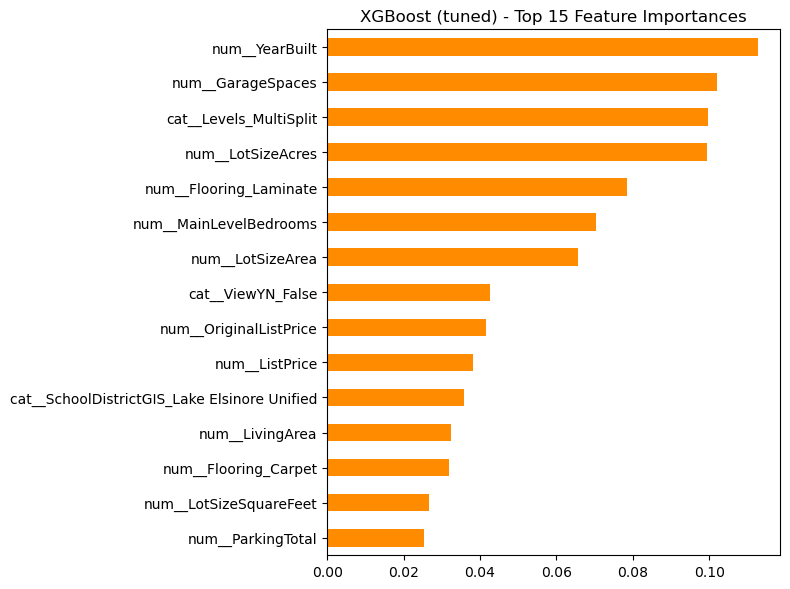

num__YearBuilt                                  0.112868
num__GarageSpaces                               0.101900
cat__Levels_MultiSplit                          0.099588
num__LotSizeAcres                               0.099311
num__Flooring_Laminate                          0.078456
num__MainLevelBedrooms                          0.070236
num__LotSizeArea                                0.065719
cat__ViewYN_False                               0.042676
num__OriginalListPrice                          0.041585
num__ListPrice                                  0.038069
cat__SchoolDistrictGIS_Lake Elsinore Unified    0.035873
num__LivingArea                                 0.032286
num__Flooring_Carpet                            0.031892
num__LotSizeSquareFeet                          0.026712
num__ParkingTotal                               0.025333
dtype: float32

In [8]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh", color="darkorange")
plt.title("XGBoost (tuned) - Top 15 Feature Importances")
plt.tight_layout()
plt.show()

importances.head(15)


## 8. Compare against Linear Regression and Random Forest & record results

`LinearRegression` and `RandomForestRegressor (max_depth=5)` (the most stable Random Forest setting found in 04_model_comparison.ipynb) are retrained here on the exact same `X_train`/`X_test` used for XGBoost above, rather than reusing `baseline_model_results.csv` / `model_comparison_results.csv` - those were generated before the Week 6 feature set existed, so pulling numbers from them here could compare XGBoost against models trained on a different set of columns.


In [9]:
def evaluate(model, X, y):
    pred = model.predict(X)
    return {
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
    }

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_test_metrics = evaluate(linear_model, X_test, y_test)

forest_model = RandomForestRegressor(max_depth=5, random_state=RANDOM_STATE, n_jobs=-1)
forest_model.fit(X_train, y_train)
forest_test_metrics = evaluate(forest_model, X_test, y_test)

advanced_model_results = pd.DataFrame([
    {"model": "LinearRegression", **linear_test_metrics},
    {"model": "RandomForest (max_depth=5)", **forest_test_metrics},
    {"model": f"XGBoost (tuned: {best_params})", **xgb_test_metrics},
])
advanced_model_results["n_train_rows"] = len(X_train)
advanced_model_results["n_test_rows"] = len(X_test)
advanced_model_results = advanced_model_results[["model", "n_train_rows", "n_test_rows", "R2", "MAE", "RMSE"]]
advanced_model_results = advanced_model_results.sort_values("R2", ascending=False).reset_index(drop=True)

advanced_model_results.to_csv("advanced_model_results.csv", index=False)
print("Saved advanced_model_results.csv")
advanced_model_results


Saved advanced_model_results.csv


,model,n_train_rows,n_test_rows,R2,MAE,RMSE
0,LinearRegression,59442,12024,0.607554,256231.962885,1.051229e+06
1,RandomForest (max_depth=5),59442,12024,-1.127638,226927.757627,2.447690e+06
2,"XGBoost (tuned: {'max_depth': 7, 'learning_rat...",59442,12024,-1.243778,178624.312462,2.513608e+06


## Summary

- Model: `XGBRegressor`, tuned via a light grid search (`max_depth` x `learning_rate` × `n_estimators`, 12 combinations - see section 4) scored on a validation month carved out of the training window, not the true test month
- The winning configuration (section 6, `best_params`) is refit on the full training window and evaluated once on the true test month - see section 6's printed R2 / MAE / RMSE, and `advanced_model_tuning_results.csv` for the full validation grid
- Section 8 places XGBoost side-by-side with `LinearRegression` and `RandomForest (max_depth=5)`, all three retrained on the identical Week-6 feature set / train-test split, so the comparison in `advanced_model_results.csv` is apples-to-apples and doesn't rely on potentially stale results from 03_baseline_model.ipynb / 04_model_comparison.ipynb
- Feature importance (section 7) shows which features the tuned XGBoost model relies on most, for comparison against the Random Forest importances from 04_model_comparison.ipynb / 02_preprocessing.ipynb
- Deliverables: `advanced_model_tuning_results.csv` (validation grid), `advanced_model_results.csv` (final test metrics vs. baseline/Random Forest), this notebook (`05_advanced_models.ipynb`)
